# 03 — Feature Engineering

In this notebook we construct **predictive features** from the processed data created in the previous step.

At this stage the data consists of two separate datasets:

- **LOB data** containing order book snapshots with bid and ask prices and volumes at multiple depth levels.
- **Trade data** containing executed trades over time.

The goal of this notebook is to transform these raw structures into **useful market microstructure variables** that describe the state of the market. These features will capture aspects such as liquidity, order flow, price pressure, momentum, and short-term volatility.

The resulting features will later be combined into a **single modelling dataset** 

In [41]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

pd.set_option("display.max_columns", None)

# load in interim dataset

In [42]:
#files_trades = glob.glob(
#    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\interim\\trades*"
#)
#files_lob = glob.glob(
#    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\interim\\lob_snapshot*"
#)

files_trades = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\interim\\trade_interim*"
)
files_lob = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\interim\\lob_interim*"
)



lob_df = pd.concat([pd.read_parquet(f) for f in files_lob])
trade_df = pd.concat([pd.read_parquet(f) for f in files_trades])

lob_df = lob_df.sort_values("timestamp").reset_index(drop=True)
trade_df = trade_df.sort_values("timestamp").reset_index(drop=True)
len(trade_df)

1263499

# Creating the variables for Limit order books

In [43]:
EPS = 1e-9

In [44]:
def create_lob_price_features(df):
    df["mid_price"] = (df["lob_bids_price_1"] + df["lob_asks_price_1"]) / 2
    df["spread"] = df["lob_asks_price_1"] - df["lob_bids_price_1"]
    df["rel_spread"] = df["spread"] / (df["mid_price"] + EPS)
    return df


def lob_volume_features(df):
    df["liquidity"] = df["lob_bids_volume_1"] + df["lob_asks_volume_1"]
    df["total_bid_volume_10"] = df[[f"lob_bids_volume_{i}" for i in range(1, 11)]].sum(
        axis=1
    )
    df["total_ask_volume_10"] = df[[f"lob_asks_volume_{i}" for i in range(1, 11)]].sum(
        axis=1
    )
    df["total_book_volume"] = df["total_ask_volume_10"] + df["total_bid_volume_10"]
    df["max_bid_ask_vol_ratio"] = df["lob_bids_volume_1"] / (
        df["lob_asks_volume_1"] + EPS
    )
    return df


def lob_pressure_features(df):

    df["imbalance_1"] = (df["lob_bids_volume_1"] - df["lob_asks_volume_1"]) / (
        df["lob_bids_volume_1"] + df["lob_asks_volume_1"] + EPS
    )
    for i in range(2, 11):
        bid_col = f"lob_bids_volume_{i}"
        ask_col = f"lob_asks_volume_{i}"

        if bid_col in df.columns and ask_col in df.columns:
            bid = df[bid_col]
            ask = df[ask_col]

            df[f"lob_depth_ratio_{i}"] = np.log((bid + EPS) / (ask + EPS))




    bid_vol5 = df[[f"lob_bids_volume_{i}" for i in range(1, 6)]].sum(axis=1)
    ask_vol5 = df[[f"lob_asks_volume_{i}" for i in range(1, 6)]].sum(axis=1)

    df["imbalance_5"] = (bid_vol5 - ask_vol5) / (bid_vol5 + ask_vol5 + EPS)

    bid10 = df[[f"lob_bids_volume_{i}" for i in range(1, 11)]].sum(axis=1)
    ask10 = df[[f"lob_asks_volume_{i}" for i in range(1, 11)]].sum(axis=1)

    df["imbalance_10"] = (bid10 - ask10) / (bid10 + ask10 + EPS)

    for i in range(1, 11):
        bid_col = f"lob_bids_volume_{i}"
        ask_col = f"lob_asks_volume_{i}"

        if bid_col in df.columns and ask_col in df.columns:
            bid = df[bid_col]#.fillna(0)
            ask = df[ask_col]#.fillna(0)

            df[f"imbalance_depth_{i}"] = (bid - ask) / (bid + ask + EPS)

    df["microprice"] = (
        df["lob_bids_volume_1"] * df["lob_asks_price_1"]
        + df["lob_asks_volume_1"] * df["lob_bids_price_1"]
    ) / (df["liquidity"] + EPS)

    df["microprice_change"] = df["microprice"].diff()
    df["mid_minus_micro"] = df["mid_price"] - df["microprice"]

    numerator10 = sum(
        df[f"lob_bids_volume_{i}"] * df[f"lob_asks_price_{i}"]
        + df[f"lob_asks_volume_{i}"] * df[f"lob_bids_price_{i}"]
        for i in range(1, 11)
    )

    denominator10 = sum(
        df[f"lob_bids_volume_{i}"] + df[f"lob_asks_volume_{i}"] for i in range(1, 11)
    )
    df["microprice_weighted_10"] = numerator10 / (denominator10 + EPS)
    return df


def lob_returns_and_momentum_features(df):
    df["return_1"] = df["mid_price"].pct_change(1)
    df["return_5"] = df["mid_price"].pct_change(5)

    df["log_return_1"] = np.log(df["mid_price"]).diff(1)
    df["log_return_2"] = np.log(df["mid_price"]).diff(2)
    df["log_return_3"] = np.log(df["mid_price"]).diff(3)
    df["log_return_5"] = np.log(df["mid_price"]).diff(5)
    df["log_return_20"] = np.log(df["mid_price"]).diff(20)
    # momentum based return

    df["momentum_5_log_return_1"] = df["log_return_1"].rolling(5).mean()
    df["momentum_20_log_return_1"] = df["log_return_1"].rolling(20).mean()

    return df


def lob_volatility_features(df):
    df["vol_5"] = df["log_return_1"].rolling(5).std()
    df["vol_20"] = df["log_return_1"].rolling(20).std()

    df["realized_vol_5"] = np.sqrt((df["log_return_1"] ** 2).rolling(5).sum())
    df["realized_vol_20"] = np.sqrt((df["log_return_1"] ** 2).rolling(20).sum())
    return df


def lob_target_feature(df, horizons=(1, 5, 20)):
    for h in horizons:
        df[f"mid_price_change_{h}"] = df["mid_price"].shift(-h) - df["mid_price"]
        df[f"mid_price_change_{h}_sign"] = np.sign(df[f"mid_price_change_{h}"])
    return df

## Pipeline

In [45]:
def build_lob_feature_pipeline(df):

    df = create_lob_price_features(df)

    df = lob_volume_features(df)

    df = lob_pressure_features(df)

    df = lob_returns_and_momentum_features(df)

    df = lob_volatility_features(df)

    df = lob_target_feature(df)

    return df


# Create trade features

In [46]:
def trade_base_features(trade_df):

    df = trade_df.copy()

    df["buy_trade"] = (df["isBuyerMaker"] == False).astype(int)
    df["sell_trade"] = (df["isBuyerMaker"] == True).astype(int)

    df["buy_qty"] = df["qty"].where(df["isBuyerMaker"] == False, 0)
    df["sell_qty"] = df["qty"].where(df["isBuyerMaker"] == True, 0)

    df["price_qty"] = df["price"] * df["qty"]

    agg = df.groupby("timestamp").agg(
        trade_count=("qty", "count"),
        buy_count=("buy_trade", "sum"),
        sell_count=("sell_trade", "sum"),
        total_trade_volume=("qty", "sum"),
        buy_volume=("buy_qty", "sum"),
        sell_volume=("sell_qty", "sum"),
        avg_trade_size=("qty", "mean"),
        max_trade_size=("qty", "max"),
        min_trade_size=("qty", "min"),
        std_trade_size=("qty", "std"),
        vwap_num=("price_qty", "sum"),
    )

    agg["vwap"] = agg["vwap_num"] / (agg["total_trade_volume"] + EPS)
    agg["max_over_average"] = agg["max_trade_size"] / agg["avg_trade_size"]
    agg = agg.drop(columns="vwap_num")

    return agg.reset_index()


def trade_pressure_features(df):
    df["trade_volume_imbalance"] = (df["buy_volume"] - df["sell_volume"]) / (
        df["buy_volume"] + df["sell_volume"] + EPS
    )

    return df


def trade_change_features(df):
    df["trade_count_imbalance"] = (df["buy_count"] - df["sell_count"]) / (
        df["buy_count"] + df["sell_count"] + 1e-9
    )
    df["trade_volume_change"] = df["total_trade_volume"].diff()

    df["trade_count_change"] = df["trade_count"].diff()

    return df


def trade_lag_features(df):

    df["lag_trade_volume_imbalance_1"] = df["trade_volume_imbalance"].shift(1)
    df["lag_trade_volume_imbalance_2"] = df["trade_volume_imbalance"].shift(2)
    df["lag_trade_volume_imbalance_3"] = df["trade_volume_imbalance"].shift(3)
    df["lag_trade_volume_imbalance_5"] = df["trade_volume_imbalance"].shift(5)

    return df

## Pileline

In [47]:
def build_trade_feature_pipeline(df):
    df = trade_base_features(df)

    df = trade_pressure_features(df)

    df = trade_change_features(df)

    df = trade_lag_features(df)
    return df

In [48]:
def merge_lob_and_trade(trade_features_df, lob_features_df):
    final_df = lob_features_df.merge(trade_features_df, on="timestamp", how="left")
    return final_df

# Building features and Final dataset and saving

In [49]:
lob_with_features = build_lob_feature_pipeline(lob_df)
trade_with_features = build_trade_feature_pipeline(trade_df)
final_dataset = merge_lob_and_trade(trade_with_features, lob_with_features)

final_dataset = final_dataset.reset_index(drop=True)
trade_cols = [
    "trade_count",
    "buy_count",
    "sell_count",
    "total_trade_volume",
    "buy_volume",
    "sell_volume",
    "avg_trade_size",
    "max_trade_size",
    "min_trade_size",
    "std_trade_size",
    "vwap",
    "max_over_average",
    "trade_volume_imbalance",
    "trade_volume_change",
    "trade_count_change",
    "trade_count_imbalance",
    "lag_trade_volume_imbalance_1",
    "lag_trade_volume_imbalance_2",
    "lag_trade_volume_imbalance_3",
    "lag_trade_volume_imbalance_5",
]

final_dataset[trade_cols] = final_dataset[trade_cols].fillna(0)
final_dataset.dropna(inplace=True)
PATH = "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\processed\\final_dataset_40k.parquet"

final_dataset.to_parquet(
    PATH,
    compression="snappy",
)
len(final_dataset)

43999

In [50]:
final_dataset.head(25)

,timestamp,lob_bids_price_1,lob_bids_price_2,lob_bids_price_3,lob_bids_price_4,lob_bids_price_5,lob_bids_price_6,lob_bids_price_7,lob_bids_price_8,lob_bids_price_9,lob_bids_price_10,lob_bids_volume_1,lob_bids_volume_2,lob_bids_volume_3,lob_bids_volume_4,lob_bids_volume_5,lob_bids_volume_6,lob_bids_volume_7,lob_bids_volume_8,lob_bids_volume_9,lob_bids_volume_10,lob_asks_price_1,lob_asks_price_2,lob_asks_price_3,lob_asks_price_4,lob_asks_price_5,lob_asks_price_6,lob_asks_price_7,lob_asks_price_8,lob_asks_price_9,lob_asks_price_10,lob_asks_volume_1,lob_asks_volume_2,lob_asks_volume_3,lob_asks_volume_4,lob_asks_volume_5,lob_asks_volume_6,lob_asks_volume_7,lob_asks_volume_8,lob_asks_volume_9,lob_asks_volume_10,mid_price,spread,rel_spread,liquidity,total_bid_volume_10,total_ask_volume_10,total_book_volume,max_bid_ask_vol_ratio,imbalance_1,lob_depth_ratio_2,lob_depth_ratio_3,lob_depth_ratio_4,lob_depth_ratio_5,lob_depth_ratio_6,lob_depth_ratio_7,lob_depth_ratio_8,lob_depth_ratio_9,lob_depth_ratio_10,imbalance_5,imbalance_10,imbalance_depth_1,imbalance_depth_2,imbalance_depth_3,imbalance_depth_4,imbalance_depth_5,imbalance_depth_6,imbalance_depth_7,imbalance_depth_8,imbalance_depth_9,imbalance_depth_10,microprice,microprice_change,mid_minus_micro,microprice_weighted_10,return_1,return_5,log_return_1,log_return_2,log_return_3,log_return_5,log_return_20,momentum_5_log_return_1,momentum_20_log_return_1,vol_5,vol_20,realized_vol_5,realized_vol_20,mid_price_change_1,mid_price_change_1_sign,mid_price_change_5,mid_price_change_5_sign,mid_price_change_20,mid_price_change_20_sign,trade_count,buy_count,sell_count,total_trade_volume,buy_volume,sell_volume,avg_trade_size,max_trade_size,min_trade_size,std_trade_size,vwap,max_over_average,trade_volume_imbalance,trade_count_imbalance,trade_volume_change,trade_count_change,lag_trade_volume_imbalance_1,lag_trade_volume_imbalance_2,lag_trade_volume_imbalance_3,lag_trade_volume_imbalance_5
20,1773138535387,70794.34,70794.33,70792.78,70792.77,70792.76,70792.21,70791.84,70791.15,70790.33,70790.32,1.13277,0.00032,0.00024,0.01925,0.04672,0.00008,0.00008,0.00200,0.00024,0.01080,70794.35,70794.36,70795.20,70795.34,70795.69,70795.99,70796.00,70796.10,70796.40,70796.46,2.19180,0.00024,0.00008,0.00300,0.00008,0.01518,0.04692,0.00159,0.00008,0.00200,70794.345,0.01,1.412542e-07,3.32457,1.21250,2.26097,3.47347,0.516822,-0.318546,0.287681,1.098604,1.858898,6.369889,-5.245695,-6.374160,0.229413,1.098604,1.686399,-0.293386,-0.301851,-0.318546,0.142857,0.499998,0.730337,0.996581,-0.989515,-0.996596,0.114206,0.499998,0.687500,70794.343386,0.000462,0.001614,70794.326451,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000243,0.000000,0.000012,0.000000,0.000048,0.000000,0.000214,0.00,0.0,0.00,0.0,-2.81,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,1773138536380,70794.34,70794.33,70792.78,70792.77,70792.76,70792.21,70791.84,70790.33,70790.32,70789.39,0.94466,0.00040,0.00024,0.01925,0.04672,0.00008,0.00008,0.00024,0.01080,0.00008,70794.35,70794.36,70794.69,70795.20,70795.34,70795.69,70795.99,70796.00,70796.10,70796.40,2.19138,0.00016,0.00200,0.00008,0.00300,0.00008,0.01526,0.04692,0.00159,0.00008,70794.345,0.01,1.412542e-07,3.13604,1.02255,2.26055,3.28310,0.431080,-0.397546,0.916287,-2.120260,5.483227,2.745560,0.000000,-5.250951,-5.275556,1.915812,0.000000,-0.369511,-0.377083,-0.397546,0.428571,-0.785714,0.991723,0.879324,0.000000,-0.989570,-0.989822,0.743341,0.000000,70794.342990,-0.000396,0.002010,70794.294710,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000243,0.000000,0.000012,0.000000,0.000048,0.000000,0.000214,0.00,0.0,0.00,0.0,-2.81,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22,1773138537379,70794.34,70794.33,70792.78,70792.77,70792.76,70792.21,70792.19,70792.18,70791.84,70790.33,0.93476,0.00040,0.00008,0.00024,0.04672,0.00008,0.00016,0.01205,0.00008,0.00024,70794.35,70794.36,70794.69,70795.20,70795.34,70795.69,70795

In [51]:
nan_counts = final_dataset.isna().sum()
final_dataset.groupby("timestamp").size().describe()

count    43999.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

,mid_price,log_return_20
20,70794.345,0.000243
21,70794.345,0.000243
22,70794.345,0.000243
23,70794.345,0.000243
24,70794.345,0.000243
25,70794.345,0.000243
26,70794.345,0.000243
27,70794.345,0.000243
28,70794.345,0.000243
29,70794.345,0.000243


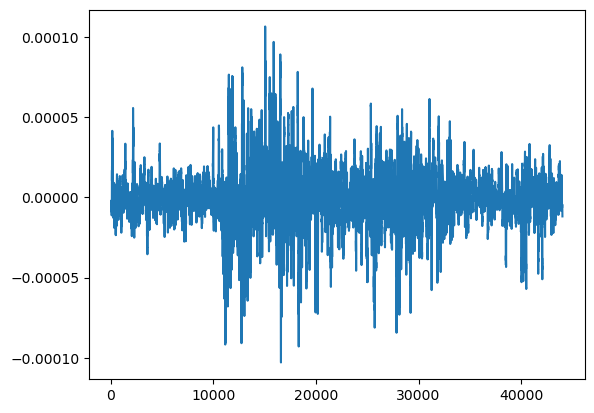

In [52]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


#final_dataset["log_return_20"].plot()
#final_dataset["log_return_1"].plot()
final_dataset["log_return_1"].rolling(50).mean().plot()

final_dataset[["mid_price", "log_return_20"]].head(25)

# Batch friendly Version for bigger datasets (NEEDS FIXING FOR ROLLING VALUES)

In [53]:
from microstructure_alpha.features.lob_features import build_lob_feature_pipeline
from microstructure_alpha.features.trade_features import build_trade_feature_pipeline
from microstructure_alpha.features.merge_features import merge_lob_and_trade
from microstructure_alpha.utils.logger import setup_logger
import time
import glob
from pathlib import Path
import gc
from tqdm import tqdm
import pandas as pd

In [54]:
logger = setup_logger(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\logs\\feature_engineering_notebook.log"
)

In [55]:
import glob
import re

def get_sorted_files(path, prefix):
    files = glob.glob(path + f"{prefix}_*")

    return sorted(
        files,
        key=lambda x: int(re.search(rf"{prefix}_(\d+)", x).group(1))
    )

In [56]:
def run_batch_feature_engineering_pipeline(
    lob_path: str, trade_path: str, save_path: str
):
    files_trade = sorted(glob.glob(trade_path + "trade_interim_*"))
    files_lob = sorted(glob.glob(lob_path + "lob_interim_*"))

    logger.info("Starting batch feature pipeline")
    logger.info(f"Found {len(files_trade)} trade files")
    logger.info(f"Found {len(files_lob)} lob files")

    total_batches = min(len(files_trade), len(files_lob))
    logger.info(f"Processing {total_batches} batches")

    BUFFER_SIZE = 200
    trade_buffer = pd.DataFrame()
    lob_buffer = pd.DataFrame()
    for i, (trade_file, lob_file) in tqdm(
        enumerate(zip(files_trade, files_lob)),
        total=total_batches,
        desc="Processing batches",
    ):

        lob_df = pd.read_parquet(lob_file)
        trade_df = pd.read_parquet(trade_file)

        lob_df = lob_df.sort_values("timestamp")
        trade_df = trade_df.sort_values("timestamp")



        lob_with_features = build_lob_feature_pipeline(lob_df,lob_buffer)

        trade_with_features = build_trade_feature_pipeline(trade_df,trade_buffer)

        if trade_buffer.empty:
            trade_buffer = trade_with_features.tail(BUFFER_SIZE)
        else:
            trade_buffer = pd.concat([trade_buffer, trade_with_features], ignore_index=True).tail(BUFFER_SIZE)

        if lob_buffer.empty:
            lob_buffer = lob_with_features.tail(BUFFER_SIZE)
        else:
            lob_buffer = pd.concat([lob_buffer, lob_with_features], ignore_index=True).tail(BUFFER_SIZE)


        final_dataset = merge_lob_and_trade(trade_with_features, lob_with_features)

        final_dataset.to_parquet(save_path + f"final_dataset_{i}.parquet", compression="snappy")
    logger.info("Batch feature pipeline completed successfully")
    return

In [57]:
trade_path = "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\interim\\"

lob_path = "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\interim\\"

save_path = "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\processed\\"

RUN_PIPELINE = False
if RUN_PIPELINE:
    run_batch_feature_engineering_pipeline(lob_path, trade_path, save_path)

In [58]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load all batch outputs
files = sorted(glob.glob(save_path + "final_dataset_*"))

df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

# FIX ordering
df = (
    df.sort_values("timestamp")
      .drop_duplicates("timestamp", keep="last")
      .reset_index(drop=True)
)

In [59]:
df["log_return_1"] = np.log(df["mid_price"]).diff()

,mid_price,log_return_20
0,70794.345,0.000243
1,70794.345,0.000243
2,70794.345,0.000243
3,70794.345,0.000243
4,70794.345,0.000243
5,70794.345,0.000243
6,70794.345,0.000243
7,70794.345,0.000243
8,70794.345,0.000243
9,70794.345,0.000243


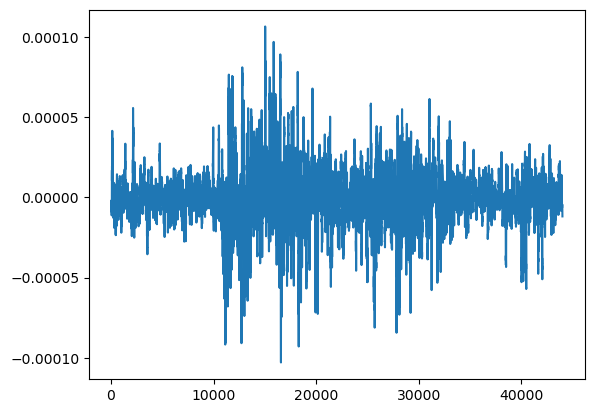

In [60]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


#final_dataset["log_return_20"].plot()
#final_dataset["log_return_1"].plot()
df["log_return_1"].rolling(50).mean().plot()

df[["mid_price", "log_return_20"]].head(25)